In [1]:

!pip install -U pip setuptools==68.0.0 wheel

!pip install \
    numpy==1.24.3 \
    pandas==2.0.3 \
    pytorch_lightning==2.0.6 \
    scikit_learn==1.3.1 \
    torch==2.0.1 \
    tqdm==4.65.0 \
    transformers==4.33.3 \
    peft==0.5.0 \
    accelerate==0.23.0

!pip install microformer-mgm

!pip uninstall -y jax jaxlib

In [2]:
!mgm --help

Starting MGM...
usage: mgm [-h] [-i INPUT] [-o OUTPUT] [-k KEY] [-c CONFIG] [-l LABELS]
           [-m MODEL] [-s VAL_SPLIT] [-H LOG] [--seed SEED] [--no-normalize]
           [--with-label] [--from-scratch] [-E] [-n NUM_SAMPLES] [-p PROMPT]
           [-a ABU] [-r RECONMODEL] [-w WITHLABEL] [-g GENERATOR]
           {construct,map,pretrain,train,finetune,predict,generate,reconstruct}

MGM (Microbiao General Model) is a large-scaled pretrained language model for interpretable microbiome data analysis.
The program is designed to help you to fine-tune and evaluate MGMto other  microbiome data analysis tasks.
Feel free to contact us if you have any question.
For more information, see Github. Thank you for using MGM!

positional arguments:
  {construct,map,pretrain,train,finetune,predict,generate,reconstruct}
                        The work mode for expert program.

options:
  -h, --help            show this help message and exit
  -i INPUT, --input INPUT
                        The input

In [3]:
!python -c "import mgm, os; print(os.path.dirname(mgm.__file__))"

/usr/local/lib/python3.11/dist-packages/mgm


In [4]:
import mgm
import os

mgm_path = os.path.dirname(mgm.__file__)
print(mgm_path)

for root, dirs, files in os.walk(mgm_path):
    level = root.replace(mgm_path, '').count(os.sep)
    if level < 3:
        print("  "*level + os.path.basename(root) + "/")
        for f in files[:5]:
            print("  "*(level+1) + f)

/usr/local/lib/python3.11/dist-packages/mgm
mgm/
  version.py
  __init__.py
  __pycache__/
    __init__.cpython-311.pyc
    version.cpython-311.pyc
  resources/
    config.ini
    phylogeny.csv
    MicroTokenizer.pkl
    general_model/
      config.json
      pytorch_model.bin
      training_args.bin
      generation_config.json
  src/
    Reconstructor.py
    __init__.py
    utils.py
    evaluator.py
    MultiLabel_utils.py
    __pycache__/
      __init__.cpython-311.pyc
      Reconstructor.cpython-311.pyc
      evaluator.cpython-311.pyc
      MicroCorpus.cpython-311.pyc
      utils.cpython-311.pyc
  CLI/
    main_train.py
    main_pretrain.py
    main_reconstruct.py
    __init__.py
    CLI_utils.py
    __pycache__/
      __init__.cpython-311.pyc
      main_pretrain.cpython-311.pyc
      main_generate.cpython-311.pyc
      main_finetune.cpython-311.pyc
      main_construct.cpython-311.pyc


In [5]:
!mgm pretrain --help

Starting MGM...
usage: mgm [-h] [-i INPUT] [-o OUTPUT] [-k KEY] [-c CONFIG] [-l LABELS]
           [-m MODEL] [-s VAL_SPLIT] [-H LOG] [--seed SEED] [--no-normalize]
           [--with-label] [--from-scratch] [-E] [-n NUM_SAMPLES] [-p PROMPT]
           [-a ABU] [-r RECONMODEL] [-w WITHLABEL] [-g GENERATOR]
           {construct,map,pretrain,train,finetune,predict,generate,reconstruct}

MGM (Microbiao General Model) is a large-scaled pretrained language model for interpretable microbiome data analysis.
The program is designed to help you to fine-tune and evaluate MGMto other  microbiome data analysis tasks.
Feel free to contact us if you have any question.
For more information, see Github. Thank you for using MGM!

positional arguments:
  {construct,map,pretrain,train,finetune,predict,generate,reconstruct}
                        The work mode for expert program.

options:
  -h, --help            show this help message and exit
  -i INPUT, --input INPUT
                        The input

In [6]:
import os
import mgm

mgm_path = os.path.dirname(mgm.__file__)

model_path = os.path.join(
    mgm_path,
    "resources",
    "general_model"
)

tokenizer_path = os.path.join(
    mgm_path,
    "resources",
    "MicroTokenizer.pkl"
)

print(model_path)
print(tokenizer_path)

/usr/local/lib/python3.11/dist-packages/mgm/resources/general_model
/usr/local/lib/python3.11/dist-packages/mgm/resources/MicroTokenizer.pkl


In [7]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_path
)

In [8]:
import pickle
import sys
import os

mgm_path = "/usr/local/lib/python3.11/dist-packages/mgm"

sys.path.append(mgm_path)

print(sys.path[-1])
with open(tokenizer_path, "rb") as f:
    tokenizer = pickle.load(f)

print(type(tokenizer))

/usr/local/lib/python3.11/dist-packages/mgm
<class 'src.MicroCorpus.MicroTokenizer'>


In [9]:
tokenizer.vocab

{'<pad>': 0,
 '<mask>': 1,
 '<bos>': 2,
 '<eos>': 3,
 'g__Abarenicola': 4,
 'g__Abedinium': 5,
 'g__Abeoforma': 6,
 'g__Aberranta': 7,
 'g__Abies': 8,
 'g__Abiotrophia': 9,
 'g__Ablabesmyia': 10,
 'g__Abolboda': 11,
 'g__Abollifer': 12,
 'g__Abraliopsis': 13,
 'g__Absidia': 14,
 'g__Abyssicoccus': 15,
 'g__Abyssivirga': 16,
 'g__Acanthamoeba': 17,
 'g__Acanthephyra': 18,
 'g__Acanthiella': 19,
 'g__Acanthobdella': 20,
 'g__Acanthobothrium': 21,
 'g__Acanthocephalus': 22,
 'g__Acanthoceras': 23,
 'g__Acanthochiasma': 24,
 'g__Acanthocolla': 25,
 'g__Acanthocorbis': 26,
 'g__Acanthocyclops': 27,
 'g__Acanthocyrta': 28,
 'g__Acanthodasys': 29,
 'g__Acanthoeca': 30,
 'g__Acantholeberis': 31,
 'g__Acantholichen': 32,
 'g__Acanthomacrostomum': 33,
 'g__Acanthometra': 34,
 'g__Acanthometron': 35,
 'g__Acanthopharynx': 36,
 'g__Acanthopleuribacter': 37,
 'g__Acanthoptilum': 38,
 'g__Acanthostaurus': 39,
 'g__Acanthostigma': 40,
 'g__Acaricomes': 41,
 'g__Acaromyces': 42,
 'g__Acarospora': 43,


In [10]:
#PRUEBA
import pandas as pd

abundance = pd.DataFrame({
    "Sample_001": [
        1000,
        500,
        250,
        100,
        50
    ]
}, index=[
    "Streptococcus",
    "Veillonella",
    "Neisseria",
    "Haemophilus",
    "Prevotella"
])

abundance

,Sample_001
Streptococcus,1000
Veillonella,500
Neisseria,250
Haemophilus,100
Prevotella,50


In [11]:
!head test_abundance.csv

head: cannot open 'test_abundance.csv' for reading: No such file or directory


In [12]:
import pandas as pd

phylo_path = "/usr/local/lib/python3.11/dist-packages/mgm/resources/phylogeny.csv"

phylo = pd.read_csv(phylo_path)

phylo.head()

,#SampleID,mean,std
0,g__Abarenicola,5.795876e-07,0.000148
1,g__Abedinium,2.248178e-05,0.000717
2,g__Abeoforma,4.592227e-06,0.000219
3,g__Aberranta,3.195448e-09,0.000001
4,g__Abies,4.417655e-08,0.000014


In [13]:
import pandas as pd

phylo_path = "/usr/local/lib/python3.11/dist-packages/mgm/resources/phylogeny.csv"

phylo = pd.read_csv(phylo_path)

# seleccionar géneros bacterianos reales presentes en MGM
test_genera = [
    "g__Streptococcus",
    "g__Veillonella",
    "g__Neisseria",
    "g__Haemophilus",
    "g__Prevotella"
]

# comprobar que existen
for g in test_genera:
    print(g, g in phylo["#SampleID"].values)

abundance = pd.DataFrame(
    {
        "Sample_001": [
            1000,
            500,
            250,
            100,
            50
        ]
    },
    index=test_genera
)

abundance

g__Streptococcus True
g__Veillonella True
g__Neisseria True
g__Haemophilus True
g__Prevotella True


,Sample_001
g__Streptococcus,1000
g__Veillonella,500
g__Neisseria,250
g__Haemophilus,100
g__Prevotella,50


In [14]:
abundance.to_csv("test_abundance.csv")

In [15]:
!mgm construct \
-i test_abundance.csv \
-o test_corpus.pkl

Starting MGM...
No config file provided, use default config file.
No seed provided, the program will generate a random seed.
Your data will be normalized with the phylogeny mean and std. If you wish to use your own normalization, please use --no-normalize.
0 samples are dropped for all zeroes
100% 1/1 [00:00<00:00, 705.52it/s]
Total 1 samples.
            Max length is 7.
            Average length is 7.0.
            Min length is 7.


In [16]:
import pickle

with open("test_corpus.pkl", "rb") as f:
    corpus = pickle.load(f)

print(type(corpus))

<class 'mgm.src.MicroCorpus.MicroCorpus'>


In [17]:
print(corpus[0])

{'input_ids': tensor([   2, 9429, 8597, 5803, 3840, 7158,    3,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0, 

In [18]:
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_tokens',
 '_additional_special_tokens',
 '_auto_class',
 '_batch_encode_plus',
 '_batch_prepare_for_model',
 '_bos_token',
 '_call_one',
 '_cls_token',
 '_convert_id_to_token',
 '_convert_token_to_id',
 '_convert_token_to_id_with_added_voc',
 '_create_repo',
 '_create_trie',
 '_decode',
 '_decode_use_source_tokenizer',
 '_encode_plus',
 '_eos_token',
 '_eventual_warn_about_too_long_sequence',
 '_eventually_correct_t5_max_length',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_targe

In [19]:
# Tamaño del vocabulario
print("Número de tokens:", tokenizer.vocab_size)
# Ver algunos tokens del vocabulario
list(tokenizer.vocab.items())[:20]

Número de tokens: 9669


[('<pad>', 0),
 ('<mask>', 1),
 ('<bos>', 2),
 ('<eos>', 3),
 ('g__Abarenicola', 4),
 ('g__Abedinium', 5),
 ('g__Abeoforma', 6),
 ('g__Aberranta', 7),
 ('g__Abies', 8),
 ('g__Abiotrophia', 9),
 ('g__Ablabesmyia', 10),
 ('g__Abolboda', 11),
 ('g__Abollifer', 12),
 ('g__Abraliopsis', 13),
 ('g__Absidia', 14),
 ('g__Abyssicoccus', 15),
 ('g__Abyssivirga', 16),
 ('g__Acanthamoeba', 17),
 ('g__Acanthephyra', 18),
 ('g__Acanthiella', 19)]

In [20]:
sample = corpus[0]

input_ids = sample["input_ids"]

print(input_ids)

tokens = tokenizer.convert_ids_to_tokens(input_ids)

tokens

tensor([   2, 9429, 8597, 5803, 3840, 7158,    3,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,   

['<bos>',
 'g__Veillonella',
 'g__Streptococcus',
 'g__Neisseria',
 'g__Haemophilus',
 'g__Prevotella',
 '<eos>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad

In [21]:
print(tokenizer.decode(input_ids))

<bos> g__Veillonella g__Streptococcus g__Neisseria g__Haemophilus g__Prevotella <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <p

In [22]:
sample["attention_mask"]

tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 

In [25]:
import pandas as pd

counts = pd.read_csv(
    "NHANES_MGM_genus_counts.csv",
    index_col=0
)

counts.head()

,57816.0,59605.0,56372.0,55484.0,55685.0,55743.0,71267.0,66184.0,56831.0,58573.0,...,65763.0,66735.0,67187.0,64256.0,56213.0,52242.0,59571.0,60334.0,60221.0,65692.0
g__Bryocella,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Candidatus_Koribacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Edaphobacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Bryobacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Candidatus_Solibacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
counts.head()

,57816.0,59605.0,56372.0,55484.0,55685.0,55743.0,71267.0,66184.0,56831.0,58573.0,...,65763.0,66735.0,67187.0,64256.0,56213.0,52242.0,59571.0,60334.0,60221.0,65692.0
g__Bryocella,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Candidatus_Koribacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Edaphobacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Bryobacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
g__Candidatus_Solibacter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
!mgm construct -i NHANES_MGM_genus_counts.csv -o NHANES_corpus.pkl

Starting MGM...
No config file provided, use default config file.
No seed provided, the program will generate a random seed.
Your data will be normalized with the phylogeny mean and std. If you wish to use your own normalization, please use --no-normalize.
33 samples are dropped for all zeroes
100% 9815/9815 [00:05<00:00, 1714.07it/s]
Total 9815 samples.
            Max length is 133.
            Average length is 49.45756495160469.
            Min length is 3.


In [28]:
import pickle

with open("NHANES_corpus.pkl", "rb") as f:
    corpus = pickle.load(f)

print(type(corpus))
print(len(corpus))

<class 'mgm.src.MicroCorpus.MicroCorpus'>
9815


In [29]:
sample = corpus[0]

print(sample.keys())

dict_keys(['input_ids', 'attention_mask'])


In [30]:
print(sample["input_ids"][:20])

tensor([   2, 8050, 3584, 8597, 4831, 7858, 1291, 8582, 3768,  486, 4649, 3840,
        9429,  160,  148, 2384, 5803, 7120, 1421,  386])


In [31]:
tokens = tokenizer.convert_ids_to_tokens(
    sample["input_ids"]
)

tokens[:50]

['<bos>',
 'g__Scardovia',
 'g__Gemella',
 'g__Streptococcus',
 'g__Leptotrichia',
 'g__Rothia',
 'g__Bulleidia',
 'g__Stomatobaculum',
 'g__Granulicatella',
 'g__Anaeroglobus',
 'g__Lachnoanaerobaculum',
 'g__Haemophilus',
 'g__Veillonella',
 'g__Actinomyces',
 'g__Actinobacillus',
 'g__Cryptobacterium',
 'g__Neisseria',
 'g__Porphyromonas',
 'g__Campylobacter',
 'g__Alysiella',
 'g__Aggregatibacter',
 'g__Kingella',
 'g__Atopobium',
 'g__Oribacterium',
 'g__Megasphaera',
 'g__Prevotella',
 'g__Fusobacterium',
 'g__Alloscardovia',
 'g__Solobacterium',
 'g__Tannerella',
 'g__Capnocytophaga',
 'g__Selenomonas',
 'g__Catonella',
 'g__Cardiobacterium',
 'g__Mogibacterium',
 'g__Alloprevotella',
 'g__Parvimonas',
 'g__Streptobacillus',
 'g__Bergeyella',
 'g__Sneathia',
 'g__Corynebacterium',
 'g__Fretibacterium',
 'g__Peptoclostridium',
 'g__Shuttleworthia',
 'g__Mycoplasma',
 'g__Abiotrophia',
 'g__Olsenella',
 'g__Lautropia',
 'g__Peptostreptococcus',
 'g__Moraxella']

In [32]:
print(tokenizer.decode(sample["input_ids"]))

<bos> g__Scardovia g__Gemella g__Streptococcus g__Leptotrichia g__Rothia g__Bulleidia g__Stomatobaculum g__Granulicatella g__Anaeroglobus g__Lachnoanaerobaculum g__Haemophilus g__Veillonella g__Actinomyces g__Actinobacillus g__Cryptobacterium g__Neisseria g__Porphyromonas g__Campylobacter g__Alysiella g__Aggregatibacter g__Kingella g__Atopobium g__Oribacterium g__Megasphaera g__Prevotella g__Fusobacterium g__Alloscardovia g__Solobacterium g__Tannerella g__Capnocytophaga g__Selenomonas g__Catonella g__Cardiobacterium g__Mogibacterium g__Alloprevotella g__Parvimonas g__Streptobacillus g__Bergeyella g__Sneathia g__Corynebacterium g__Fretibacterium g__Peptoclostridium g__Shuttleworthia g__Mycoplasma g__Abiotrophia g__Olsenella g__Lautropia g__Peptostreptococcus g__Moraxella g__Peptoniphilus g__Bifidobacterium g__Dialister g__Lactobacillus <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pa

In [33]:
!mgm pretrain --help

Starting MGM...
usage: mgm [-h] [-i INPUT] [-o OUTPUT] [-k KEY] [-c CONFIG] [-l LABELS]
           [-m MODEL] [-s VAL_SPLIT] [-H LOG] [--seed SEED] [--no-normalize]
           [--with-label] [--from-scratch] [-E] [-n NUM_SAMPLES] [-p PROMPT]
           [-a ABU] [-r RECONMODEL] [-w WITHLABEL] [-g GENERATOR]
           {construct,map,pretrain,train,finetune,predict,generate,reconstruct}

MGM (Microbiao General Model) is a large-scaled pretrained language model for interpretable microbiome data analysis.
The program is designed to help you to fine-tune and evaluate MGMto other  microbiome data analysis tasks.
Feel free to contact us if you have any question.
For more information, see Github. Thank you for using MGM!

positional arguments:
  {construct,map,pretrain,train,finetune,predict,generate,reconstruct}
                        The work mode for expert program.

options:
  -h, --help            show this help message and exit
  -i INPUT, --input INPUT
                        The input

In [34]:
!mgm pretrain \
-i NHANES_corpus.pkl \
-m /usr/local/lib/python3.11/dist-packages/mgm/resources/general_model \
-o MGM_NHANES_DAPT

Starting MGM...
No config file provided, use default config file.
No seed provided, the program will generate a random seed.
2026-08-04 19:01:48.873973: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785870108.896482    3001 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785870108.903287    3001 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-04 19:01:48.925660: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler

In [38]:
!zip -r MGM_NHANES_DAPT.zip MGM_NHANES_DAPT

  adding: MGM_NHANES_DAPT/ (stored 0%)
  adding: MGM_NHANES_DAPT/config.json (deflated 49%)
  adding: MGM_NHANES_DAPT/pytorch_model.bin (deflated 7%)
  adding: MGM_NHANES_DAPT/training_args.bin (deflated 49%)
  adding: MGM_NHANES_DAPT/generation_config.json (deflated 29%)


In [40]:
import zipfile

with zipfile.ZipFile('MGM_NHANES_DAPT.zip', 'r') as zip_ref:
    zip_ref.extractall('MGM_NHANES_DAPT')

In [41]:
from transformers import AutoModelForCausalLM

model_dapt = AutoModelForCausalLM.from_pretrained("MGM_NHANES_DAPT")

print(model_dapt.config)

GPT2Config {
  "_name_or_path": "MGM_NHANES_DAPT",
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 2,
  "embd_pdrop": 0.1,
  "eos_token_id": 3,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_embd": 256,
  "n_head": 8,
  "n_inner": null,
  "n_layer": 8,
  "n_positions": 512,
  "pad_token_id": 0,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "torch_dtype": "float32",
  "transformers_version": "4.33.3",
  "use_cache": true,
  "vocab_size": 9669
}



In [42]:
print(model.config)

GPT2Config {
  "_name_or_path": "/usr/local/lib/python3.11/dist-packages/mgm/resources/general_model",
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 2,
  "embd_pdrop": 0.1,
  "eos_token_id": 3,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_embd": 256,
  "n_head": 8,
  "n_inner": null,
  "n_layer": 8,
  "n_positions": 512,
  "pad_token_id": 0,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "torch_dtype": "float32",
  "transformers_version": "4.33.3",
  "use_cache": true,
  "vocab_size": 9669
}



In [43]:
from transformers import AutoModelForCausalLM
import torch

original = AutoModelForCausalLM.from_pretrained(
    "/usr/local/lib/python3.11/dist-packages/mgm/resources/general_model"
)

dapt = AutoModelForCausalLM.from_pretrained(
    "MGM_NHANES_DAPT"
)

p1 = original.transformer.h[0].mlp.c_fc.weight
p2 = dapt.transformer.h[0].mlp.c_fc.weight

print(torch.equal(p1, p2))

False


In [44]:
diff = torch.mean(torch.abs(p1 - p2))
print(diff.item())

0.021080514416098595


In [45]:
import pandas as pd

log = pd.read_csv("MGM_log/pretrain_log.csv")
log.head()

,loss,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.5469,0.0001,0.36,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.2008,0.0002,0.72,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0927,0.0003,1.08,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0232,0.0004,1.44,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0053,0.0005,1.81,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


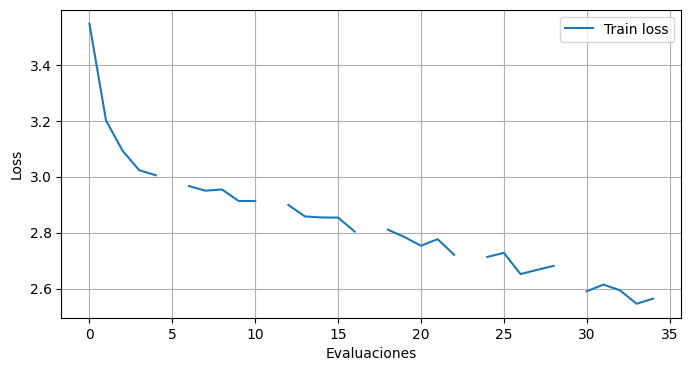

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

if "loss" in log.columns:
    plt.plot(log["loss"], label="Train loss")


plt.xlabel("Evaluaciones")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()